## For the global training - visualize the normalized data 


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.cio as cio
import matplotlib.pyplot as plt
import nibabel as nb
import Functional_Fusion.plot as ffpl

## Cortical data after scaling and combination 

In [3]:
traindata = 'MdWfIbDeHtNiSoScLa-sc'
data_cifti = nb.load(gl.conn_dir + f"/maps/{traindata}_data_cortex.pscalar.nii")
X = data_cifti.get_fdata()

In [22]:
row_axis = data_cifti.header.get_axis(0)      # ScalarAxis / LabelAxis / SeriesAxis
names = list(row_axis.name)
D=pd.DataFrame()
for r in names:
    d ={}
    parts = r.split('_')
    d['Dataset'] = [parts[0]]
    d['Task'] = parts[1]
    d['Cond'] = '_'.join(parts[2:-1])
    d['Half'] = parts[-1]
    D=pd.concat([D,pd.DataFrame(d)], ignore_index=True)
# Find the rows which are the first for each dataset
first = np.where(~D.Dataset.duplicated())[0]

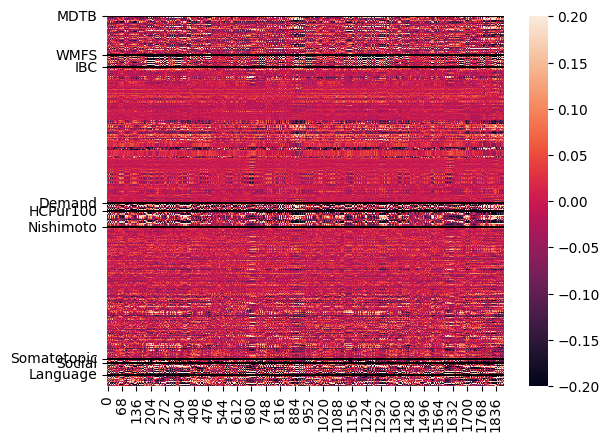

In [5]:
sns.heatmap(X,vmin=-0.2,vmax=0.2)
ax=plt.gca()
ax.set_yticks(first)
ax.set_yticklabels(D.Dataset.iloc[first])
for f in first:
    plt.axhline(f,color='k')

In [6]:
D['SS_cortex']= (X**2).sum(axis=1)
D['S_cortex']= X.sum(axis=1)
pd.pivot_table(D,index='Dataset',values='SS_cortex',aggfunc='sum')

,SS_cortex
Dataset,
Demand,1876.0
HCPur100,1876.0
IBC,1876.0
Language,1876.0
MDTB,1876.0
Nishimoto,1876.0
Social,1876.0
Somatotopic,1876.0
WMFS,1876.0


In [ ]:
# Plot cortical map
label_fs = [gl.atlas_dir + f"/tpl-fs32k/Icosahedron1002.{hemi}.label.gii" for hemi in ["L", "R"]]
cifti_img = cio.model_to_cifti((X**2).sum(axis=0),src_roi = label_fs)
S=cifti_img.get_fdata()
S.shape

/opt/miniconda3/envs/base12/lib/python3.12/site-packages/nibabel/cifti2/cifti2.py:1492: UserWarning: Dataobj shape (1876,) does not match shape expected from CIFTI-2 header (1876, 1876)
  warn(


(1876,)

## Cerebellar data after scaling and combination

In [8]:
traindata = 'MdWfIbDeHtNiSoScLa-sc'
data_ciftiC = nb.load(gl.conn_dir + f"/maps/{traindata}_data_cerebellum.dscalar.nii")
Y = data_ciftiC.get_fdata()

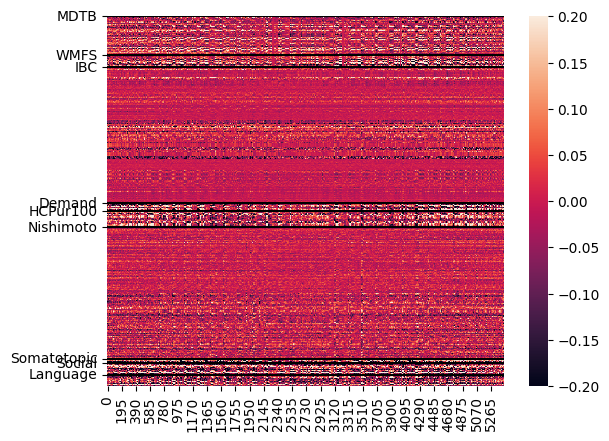

In [9]:
sns.heatmap(Y,vmin=-0.2,vmax=0.2)
ax=plt.gca()
ax.set_yticks(first)
ax.set_yticklabels(D.Dataset.iloc[first])
for f in first:
    plt.axhline(f,color='k')

In [10]:
D['SS_cereb']= (Y**2).sum(axis=1)
D['S_cereb']= Y.sum(axis=1)
pd.pivot_table(D,index='Dataset',values='SS_cereb',aggfunc='sum')

,SS_cereb
Dataset,
Demand,5446.0
HCPur100,5446.0
IBC,5446.0
Language,5446.0
MDTB,5446.0
Nishimoto,5446.0
Social,5446.0
Somatotopic,5446.0
WMFS,5446.0


<Axes: >

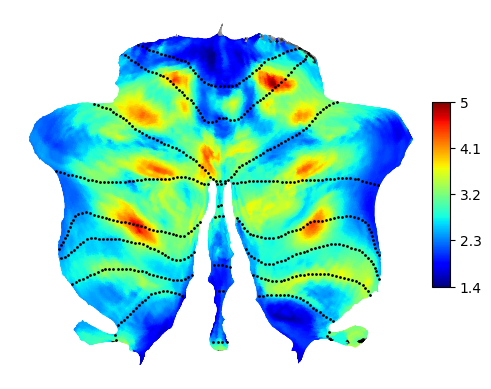

In [11]:
## Plot overall length of vector per cerebellar voxel
vector_length = np.sqrt((Y**2).sum(axis=0))
ffpl.plot_cerebellum(vector_length,colorbar=True)

## Overall reliability of the data across the two data halves


<Axes: >

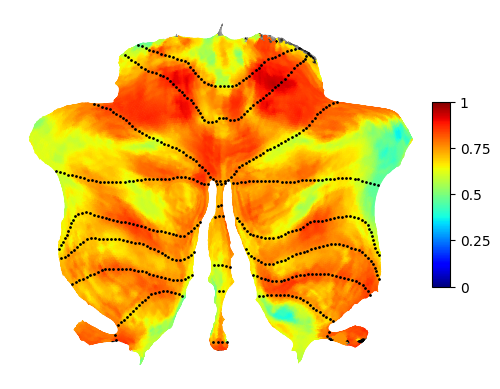

In [34]:
idx1 = np.where(D.Half=='half1')[0]
idx2 = np.where(D.Half=='half2')[0]
# Calculate cosine simimialrty between the two halves for each voxel
cossim = (Y[idx1,:]*Y[idx2,:]).sum(axis=0)/np.sqrt((Y[idx1,:]**2).sum(axis=0)*(Y[idx2,:]**2).sum(axis=0))
ffpl.plot_cerebellum(cossim,cscale=[0,1],colorbar=True)